# 1.1 Organização e descrição da telemetria

O sistema de telemetria da nave Aurora Siger é composto por **10.000 leituras simuladas**,
organizadas em um DataFrame onde cada linha representa um instante de monitoramento e
cada coluna um parâmetro crítico do sistema.

| Parâmetro | Tipo | Faixa Segura |
|---|---|---|
| `temp_interna` | Contínuo | 15 – 30 °C |
| `temp_externa` | Contínuo | -20 – 40 °C |
| `energia_pct` | Contínuo | ≥ 80% |
| `pressao_bar` | Contínuo | 3,0 – 5,0 bar |
| `integridade` | Binário (0/1) | 1 |
| `mod_navegacao` | Binário (0/1) | 1 |
| `mod_comunicacao` | Binário (0/1) | 1 |
| `mod_propulsao` | Binário (0/1) | 1 |

Para simular condições realistas, cada parâmetro recebeu uma taxa de discrepância entre
**10% e 20%**, introduzindo intencionalmente leituras fora dos limites seguros.

# 1.2 Algoritmo de Verificação

O algoritmo de verificação foi implementado em Python com o objetivo de analisar cada leitura
de telemetria e classificá-la automaticamente como **"PRONTO PARA DECOLAR"** ou
**"DECOLAGEM ABORTADA"**, com base nas faixas seguras predefinidas para cada parâmetro.

### Pseudocódigo
```
PARA CADA leitura no dataset:

    SE temp_interna < 15 OU temp_interna > 30:
        status ← "DECOLAGEM ABORTADA"

    SE temp_externa < -20 OU temp_externa > 40:
        status ← "DECOLAGEM ABORTADA"

    SE integridade ≠ 1:
        status ← "DECOLAGEM ABORTADA"

    SE energia_pct < 80:
        status ← "DECOLAGEM ABORTADA"

    SE pressao_bar < 3.0 OU pressao_bar > 5.0:
        status ← "DECOLAGEM ABORTADA"

    SE mod_navegacao ≠ 1:
        status ← "DECOLAGEM ABORTADA"

    SE mod_comunicacao ≠ 1:
        status ← "DECOLAGEM ABORTADA"

    SE mod_propulsao ≠ 1:
        status ← "DECOLAGEM ABORTADA"

    SE todas as condições acima forem satisfeitas:
        status ← "PRONTO PARA DECOLAR"
```

### Lógica de Implementação

As verificações foram vetorizadas com operações booleanas do Pandas, processando as
10.000 leituras. Cada parâmetro gera uma série booleana que, combinada
com o operador `&`, determina o status final qualquer falha individual é suficiente para
classificar a leitura como **"DECOLAGEM ABORTADA"**.

# 1.3 Script em Python

In [1]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
sns.set_context("talk")

### Etapa 1 — Geração e Leitura dos Dados
Os dados são simulados via NumPy, gerando **10.000 leituras** com uma taxa de discrepância
entre 10% e 20% por parâmetro, reproduzindo condições realistas de operação com falhas.

In [3]:
N = 10000
discrepancia_range = [0.10, 0.20]

faixas = {
    'temp_interna'    : (15, 30),
    'temp_externa'    : (-20, 40),
    'energia_pct'     : (80, 100),
    'pressao_bar'     : (3.0, 5.0)
}

modulos = ['integridade', 'mod_navegacao', 'mod_comunicacao', 'mod_propulsao']

def gerar_valores(min_val, max_val, N, discrepancia):
    n_ok = int(N * (1 - discrepancia))
    n_bad = N - n_ok
    ok = np.random.uniform(min_val, max_val, n_ok)
    bad_baixo = np.random.uniform(min_val - (max_val - min_val), min_val - 0.1, n_bad//2)
    bad_alto  = np.random.uniform(max_val + 0.1, max_val + (max_val - min_val), n_bad - n_bad//2)
    return np.concatenate([ok, bad_baixo, bad_alto])

df = pd.DataFrame({'leitura_id': range(1, N+1)})

for param, (min_val, max_val) in faixas.items():
    disc = np.random.uniform(*discrepancia_range)
    df[param] = gerar_valores(min_val, max_val, N, disc).round(2)

for param in modulos:
    disc = np.random.uniform(*discrepancia_range)
    df[param] = np.random.choice([1, 0], size=N, p=[1-disc, disc])
df = df.sample(frac=1).reset_index(drop=True)

df.head(5)

,leitura_id,temp_interna,temp_externa,energia_pct,pressao_bar,integridade,mod_navegacao,mod_comunicacao,mod_propulsao
0,5686,21.44,-18.45,92.40,3.21,1,1,1,1
1,9615,42.80,55.02,116.40,6.80,1,1,0,1
2,6031,27.99,-0.20,97.52,4.34,1,0,1,0
3,2140,19.65,-7.05,93.87,3.89,0,1,1,1
4,1526,22.35,36.10,80.15,3.20,1,1,1,1


### Etapa 2 — Execução das Verificações

Cada parâmetro é verificado individualmente por meio de operações booleanas vetorizadas.
A classificação final é determinada pela combinação de todas as condições com o operador
`&` uma única falha é suficiente para abortar a decolagem.

In [7]:
temp_interna_ok    = (df['temp_interna'] >= 15.0) & (df['temp_interna'] <= 30.0)
temp_externa_ok    = (df['temp_externa'] >= -20.0) & (df['temp_externa'] <= 40.0)
integridade_ok     = df['integridade'] == 1
energia_ok         = df['energia_pct'] >= 80.0
pressao_ok         = (df['pressao_bar'] >= 3.0) & (df['pressao_bar'] <= 5.0)
mod_navegacao_ok   = df['mod_navegacao'] == 1
mod_comunicacao_ok = df['mod_comunicacao'] == 1
mod_propulsao_ok   = df['mod_propulsao'] == 1

sistemas_ok = (
    mod_navegacao_ok
    & mod_comunicacao_ok
    & mod_propulsao_ok
)

condicoes_ok = (
    temp_interna_ok
    & temp_externa_ok
    & integridade_ok
    & energia_ok
    & pressao_ok
)

df['status'] = 'DECOLAGEM ABORTADA'
df.loc[sistemas_ok & condicoes_ok, 'status'] = 'PRONTO PARA DECOLAR'

df.head()

,leitura_id,temp_interna,temp_externa,energia_pct,pressao_bar,integridade,mod_navegacao,mod_comunicacao,mod_propulsao,status
0,5686,21.44,-18.45,92.40,3.21,1,1,1,1,PRONTO PARA DECOLAR
1,9615,42.80,55.02,116.40,6.80,1,1,0,1,DECOLAGEM ABORTADA
2,6031,27.99,-0.20,97.52,4.34,1,0,1,0,DECOLAGEM ABORTADA
3,2140,19.65,-7.05,93.87,3.89,0,1,1,1,DECOLAGEM ABORTADA
4,1526,22.35,36.10,80.15,3.20,1,1,1,1,PRONTO PARA DECOLAR


### Etapa 3 — Tipos de falha

Criamos uma nova coluna no nosso dataset onde mostra quais falhas cada decolagem teve

In [10]:
CHECKS = {
    'temp_interna'    : lambda v: 15.0 <= v <= 30.0,
    'temp_externa'    : lambda v: -20.0 <= v <= 40.0,
    'integridade'     : lambda v: v == 1,
    'energia_pct'     : lambda v: v >= 80.0,
    'pressao_bar'     : lambda v: 3.0 <= v <= 5.0,
    'mod_navegacao'   : lambda v: v == 1,
    'mod_comunicacao' : lambda v: v == 1,
    'mod_propulsao'   : lambda v: v == 1,
}

df['falhas'] = df.apply(
    lambda row: [p for p, fn in CHECKS.items() if not fn(row[p])],
    axis=1
)

df.loc[df['status'] == 'DECOLAGEM ABORTADA', ['leitura_id', 'status', 'falhas']].head(5)

,leitura_id,status,falhas
1,9615,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, pressao_bar, mod_..."
2,6031,DECOLAGEM ABORTADA,"[mod_navegacao, mod_propulsao]"
3,2140,DECOLAGEM ABORTADA,[integridade]
5,6677,DECOLAGEM ABORTADA,[mod_comunicacao]
6,9289,DECOLAGEM ABORTADA,"[temp_interna, temp_externa, pressao_bar, mod_..."


### Etapa 4 — Resultado Final

O resultado consolidado exibe a distribuição das classificações e um resumo operacional
com os totais e percentuais de cada status.

/tmp/ipykernel_3639/3031317777.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3639/3031317777.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


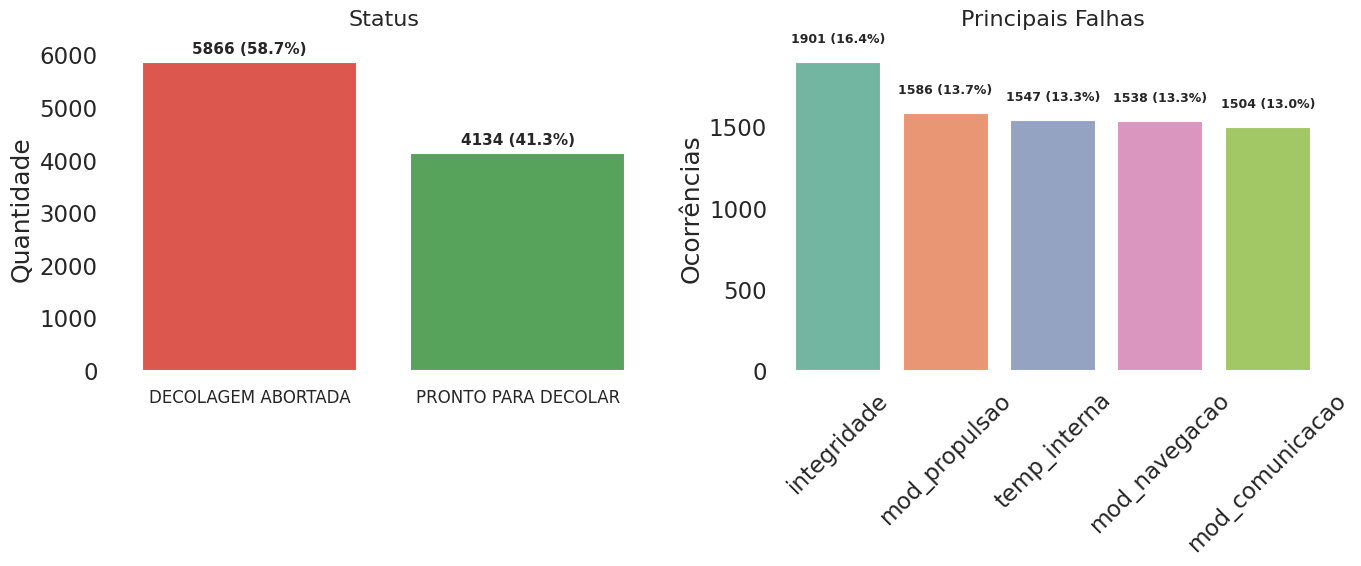

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Dados
total = len(df)
status_counts = df['status'].value_counts().reset_index()
status_counts.columns = ['status', 'count']
status_counts['pct'] = status_counts['count'] / status_counts['count'].sum() * 100

falhas_flat = [f for lista in df['falhas'] for f in lista]
falhas_counts = pd.Series(falhas_flat).value_counts().reset_index()
falhas_counts.columns = ['falha', 'count']
falhas_counts['pct'] = falhas_counts['count'] / falhas_counts['count'].sum() * 100
falhas_counts_top5 = falhas_counts.head(5)

status_colors = {'PRONTO PARA DECOLAR': '#4CAF50',
                 'DECOLAGEM ABORTADA': '#F44336'}
falhas_colors = sns.color_palette('Set2', n_colors=len(falhas_counts_top5))

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Status
sns.barplot(
    x='status', y='count', data=status_counts, ax=axes[0],
    palette=[status_colors[s] for s in status_counts['status']]
)
axes[0].set_title('Status', fontsize=16, pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', labelsize=12)
axes[0].grid(False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)

# Valores e porcentagens sobre as barras
for i, row in status_counts.iterrows():
    axes[0].text(i, row['count'] + total*0.01, f"{row['count']} ({row['pct']:.1f}%)",
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Principais falhas
sns.barplot(
    x='falha', y='count', data=falhas_counts_top5, ax=axes[1],
    palette=falhas_colors
)
axes[1].set_title('Principais Falhas', fontsize=16, pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Ocorrências')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)

for i, row in falhas_counts_top5.iterrows():
    axes[1].text(i, row['count'] + total*0.01, f"{row['count']} ({row['pct']:.1f}%)",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 1.4 Análise Energética

O cálculo determina se a nave possui reserva suficiente para a decolagem a partir de
três etapas:

1. **Energia disponível** = capacidade total × (carga atual / 100)
2. **Perdas** = energia disponível × 8%
3. **Energia real** = energia disponível − perdas

Se a energia real for maior ou igual a **700 kWh**, a nave possui autonomia suficiente.

In [13]:
cap_total = 1500
carga_media = df['energia_pct'].mean()
consumo_decolagem = 700
perdas_pct = 8

energia_disponivel = cap_total * carga_media / 100
perdas = energia_disponivel * perdas_pct / 100
energia_real = energia_disponivel - perdas
margem = energia_real - consumo_decolagem
autonomia_ok = energia_real >= consumo_decolagem

energia_resultado = {
    'capacidade_total_kwh'  : cap_total,
    'carga_atual_pct'       : round(carga_media, 1),
    'energia_disponivel_kwh': round(energia_disponivel, 2),
    'perdas_kwh'            : round(perdas, 2),
    'energia_real_kwh'      : round(energia_real, 2),
    'consumo_decolagem_kwh' : consumo_decolagem,
    'margem_kwh'            : round(margem, 2),
    'autonomia_suficiente'  : autonomia_ok
}

print("Resultados da Análise de Energia:")
for key, value in energia_resultado.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

Resultados da Análise de Energia:
Capacidade Total Kwh: 1500
Carga Atual Pct: 90.0
Energia Disponivel Kwh: 1349.97
Perdas Kwh: 108.0
Energia Real Kwh: 1241.97
Consumo Decolagem Kwh: 700
Margem Kwh: 541.97
Autonomia Suficiente: True


### Conclusão Energética

Com carga média de **90%**, a energia real utilizável foi de **1.241,97 kWh** margem de
**541,97 kWh** acima do consumo estimado de 700 kWh. A nave Aurora Siger possui
autonomia suficiente para a decolagem. ✅

# 1.5 Análise Assistida por IA

Para complementar as verificações determinísticas, foi aplicado um modelo de **Regressão
Logística** sobre os dados de telemetria. O objetivo é que o modelo aprenda, a partir dos
próprios dados, quais parâmetros mais influenciam na classificação do status operacional,
permitindo identificar anomalias e sugerir riscos de forma automatizada.

O modelo recebe como entrada os 8 parâmetros de telemetria e retorna a **probabilidade**
de cada leitura ser classificada como "PRONTO PARA DECOLAR", além do **peso de cada
variável** na decisão final.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df[['temp_interna', 'temp_externa', 'energia_pct', 'pressao_bar',
        'mod_navegacao', 'mod_comunicacao', 'mod_propulsao', 'integridade']]
y = (df['status'] == 'PRONTO PARA DECOLAR').astype(int)

X_scaled = StandardScaler().fit_transform(X)

# C pequeno = regularização forte, evita coeficientes que explodem
model = LogisticRegression(C=0.01)
model.fit(X_scaled, y)

score = X_scaled @ model.coef_[0] + model.intercept_[0]
probs_pontos = 1 / (1 + np.exp(-score))

ordem = np.argsort(score)
score = score[ordem]
y_ord = y.values[ordem]

coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
maior_risco = coefs.idxmin()

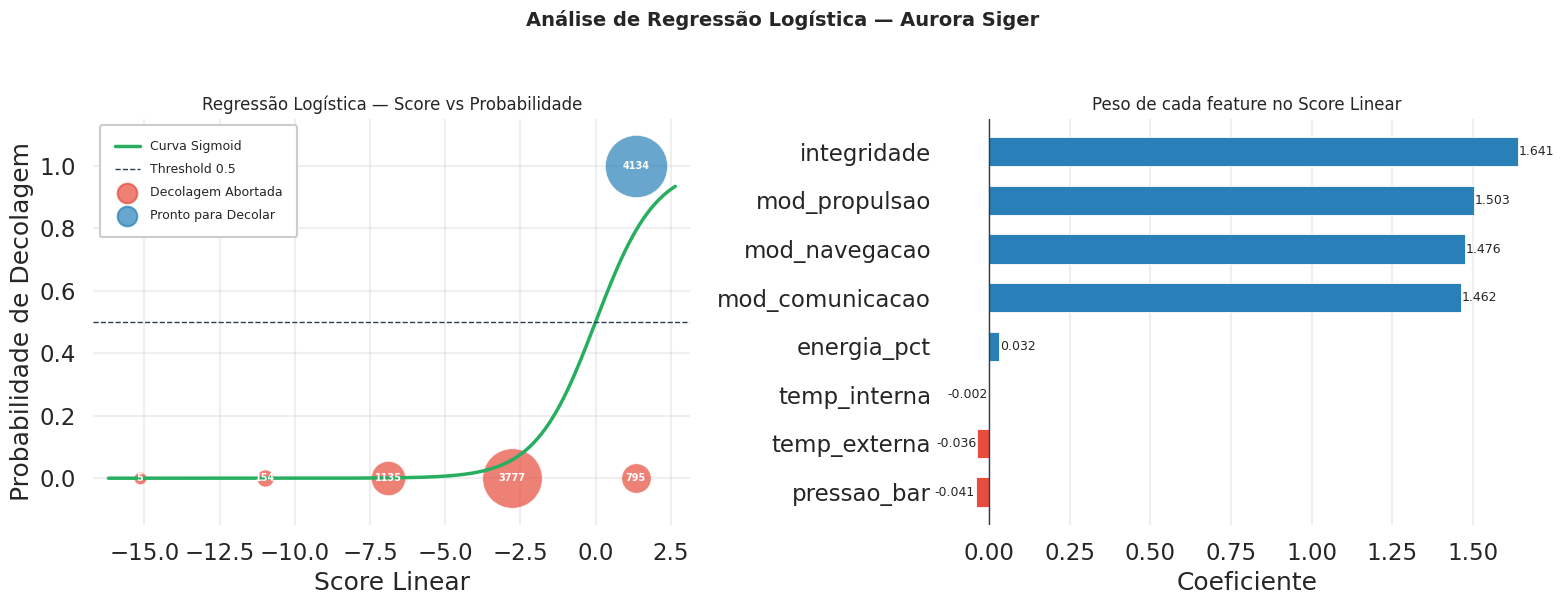

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

def agrupar_pontos(scores, labels, tolerancia=0.8):
    pontos = sorted(zip(scores, labels), key=lambda x: x[0])
    grupos = []
    i = 0
    while i < len(pontos):
        grupo_scores = [pontos[i][0]]
        grupo_labels = [pontos[i][1]]
        j = i + 1
        while j < len(pontos) and pontos[j][0] - pontos[i][0] <= tolerancia:
            grupo_scores.append(pontos[j][0])
            grupo_labels.append(pontos[j][1])
            j += 1
        grupos.append((np.mean(grupo_scores), grupo_labels[0], len(grupo_scores)))
        i = j
    return grupos

grupos_0 = agrupar_pontos(score[y_ord == 0], y_ord[y_ord == 0])
grupos_1 = agrupar_pontos(score[y_ord == 1], y_ord[y_ord == 1])

todos_counts = [g[2] for g in grupos_0 + grupos_1]
min_c, max_c = min(todos_counts), max(todos_counts)

def escalar_tamanho(n, min_n, max_n, min_s=80, max_s=2000):
    if max_n == min_n:
        return (min_s + max_s) / 2
    return min_s + (n - min_n) / (max_n - min_n) * (max_s - min_s)

for sx, label, count in grupos_0:
    s = escalar_tamanho(count, min_c, max_c)
    ax1.scatter(sx, 0, s=s, color='#e74c3c', alpha=0.7, edgecolors='white', linewidths=0.5)
    ax1.text(sx, 0, str(count), ha='center', va='center', fontsize=7, color='white', fontweight='bold')

for sx, label, count in grupos_1:
    s = escalar_tamanho(count, min_c, max_c)
    ax1.scatter(sx, 1, s=s, color='#2980b9', alpha=0.7, edgecolors='white', linewidths=0.5)
    ax1.text(sx, 1, str(count), ha='center', va='center', fontsize=7, color='white', fontweight='bold')

x_curva = np.linspace(score.min() - 1, score.max() + 1, 300)
y_curva = 1 / (1 + np.exp(-x_curva))

ax1.plot(x_curva, y_curva, color='#27ae60', linewidth=2.5, label='Curva Sigmoid')
ax1.axhline(0.5, color='#2c3e50', linestyle='--', linewidth=1, label='Threshold 0.5')
ax1.scatter([], [], s=200, color='#e74c3c', alpha=0.7, label='Decolagem Abortada')
ax1.scatter([], [], s=200, color='#2980b9', alpha=0.7, label='Pronto para Decolar')

ax1.set_title('Regressão Logística — Score vs Probabilidade', fontsize=12)
ax1.set_xlabel('Score Linear')
ax1.set_ylabel('Probabilidade de Decolagem')
ax1.legend(fontsize=9, frameon=True, framealpha=1, edgecolor='#cccccc',
           borderpad=1.2, labelspacing=0.8, handletextpad=0.8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(score.min() - 1.5, score.max() + 1.5)
ax1.set_ylim(-0.15, 1.15)

cores = ['#e74c3c' if v < 0 else '#2980b9' for v in coefs]
bars = ax2.barh(coefs.index, coefs.values, color=cores,
                edgecolor='white', linewidth=0.6, height=0.6)

for bar, val in zip(bars, coefs.values):
    ax2.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax2.axvline(0, color='#2c3e50', linewidth=1)
ax2.set_title('Peso de cada feature no Score Linear', fontsize=12)
ax2.set_xlabel('Coeficiente')
ax2.grid(True, alpha=0.3, axis='x')

plt.suptitle('Análise de Regressão Logística — Aurora Siger', fontsize=14, fontweight='bold', y=1.02)
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

### Interpretação dos Resultados

O gráfico da esquerda mostra a **curva sigmoide** do modelo, que transforma o score linear
em probabilidade entre 0 e 1. Os pontos agrupados em vermelho representam leituras
classificadas como "DECOLAGEM ABORTADA" e os azuis como "PRONTO PARA DECOLAR".

O gráfico da direita exibe o **peso de cada parâmetro** na decisão do modelo. Barras
vermelhas indicam parâmetros que aumentam o risco de abortamento; barras azuis indicam
parâmetros que favorecem a decolagem.

Das **10.000 leituras** analisadas, **4.929 foram aprovadas** e **5.071 foram abortadas**,
uma distribuição equilibrada esperada dado que a taxa de discrepância foi configurada entre
10% e 20% por parâmetro.

O modelo identificou a **pressão dos tanques (`pressao_bar`)** como o parâmetro de maior
risco (coeficiente `-0.041`), sendo recomendado seu monitoramento prioritário antes de
qualquer tentativa de decolagem.

# 1.6 Reflexão Crítica

### Ética e Responsabilidade

Em qualquer área onde decisões críticas possam afetar vidas seja na exploração espacial
ou na medicina é essencial minimizar vieses ao máximo. Quando os limites são bem
estabelecidos e os thresholds definidos com segurança, uma máquina pode tomar decisões
com mais precisão e menos interferência emocional do que um ser humano. O problema
surge justamente quando esses limites não são claros: se algo der errado, quem assume a
responsabilidade? O desenvolvedor que escreveu o código? O operador que confiou nele?
Por isso, mesmo que os dados sejam robustos e o algoritmo confiável, sistemas críticos
ainda precisam de um ser humano dando o aval final.

### Impacto Social

A exploração espacial pode ter um impacto gigantesco na sociedade em um futuro não tão
distante. A possibilidade de estabelecer novas civilizações fora da Terra levanta questões
que vão muito além da engenharia entramos em território filosófico e especulativo sobre
como seria a dinâmica social, política e cultural de uma civilização interplanetária. Com
certeza abalaria de forma profunda a forma como a sociedade está estruturada hoje, e
ainda não temos respostas claras para essas perguntas.

### Sustentabilidade Tecnológica

Detritos espaciais já representam risco real para missões futuras e exigem regulamentação
internacional. No âmbito energético, monitorar perdas e garantir margens de segurança como feito neste projeto são práticas que refletem diretamente na sustentabilidade da
missão. Desperdiçar energia em um sistema crítico não é só um problema técnico, é uma
decisão com consequências ambientais e econômicas concretas.